In [1]:
# Nếu dùng Google Colab, uncomment dòng sau:
# !pip install ultralytics scikit-learn opencv-python matplotlib seaborn

import os
import cv2
import numpy as np
from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Định nghĩa các nhãn cần phân loại
class_names = ['Hello', 'IloveYou', 'No', 'Please', 'Thanks', 'Yes']

# Thư mục chứa ảnh test
test_dir = 'data/test/images'  # Thay đổi nếu thư mục khác

# Load mô hình YOLO đã huấn luyện
model = YOLO('best.pt')  # Đường dẫn tới mô hình


In [3]:
# Biến lưu nhãn thực và nhãn dự đoán
y_true = []
y_pred = []

# Duyệt từng ảnh trong thư mục test
for fname in os.listdir(test_dir):
    if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue

    # Lấy nhãn thực từ tên file
    true_label = None
    for cname in class_names:
        if fname.lower().startswith(cname.lower()):
            true_label = cname
            break
    if true_label is None:
        continue

    # Đọc ảnh
    img_path = os.path.join(test_dir, fname)
    img = cv2.imread(img_path)
    if img is None:
        continue

    # Dự đoán bằng YOLO
    results = model.predict(source=img, conf=0.25, verbose=False)
    if results[0].boxes:
        pred_label = results[0].names[int(results[0].boxes.cls[0])]
    else:
        pred_label = "No Detection"

    # Lưu nhãn
    y_true.append(true_label)
    y_pred.append(pred_label)


In [4]:
# Báo cáo classification report
print("=== Classification Report ===")
print(classification_report(
    y_true, y_pred, labels=class_names, target_names=class_names, zero_division=0
))


=== Classification Report ===
              precision    recall  f1-score   support

       Hello       1.00      1.00      1.00         8
    IloveYou       1.00      1.00      1.00         9
          No       1.00      0.91      0.95        11
      Please       1.00      1.00      1.00         7
      Thanks       1.00      1.00      1.00         8
         Yes       1.00      1.00      1.00         9

   micro avg       1.00      0.98      0.99        52
   macro avg       1.00      0.98      0.99        52
weighted avg       1.00      0.98      0.99        52



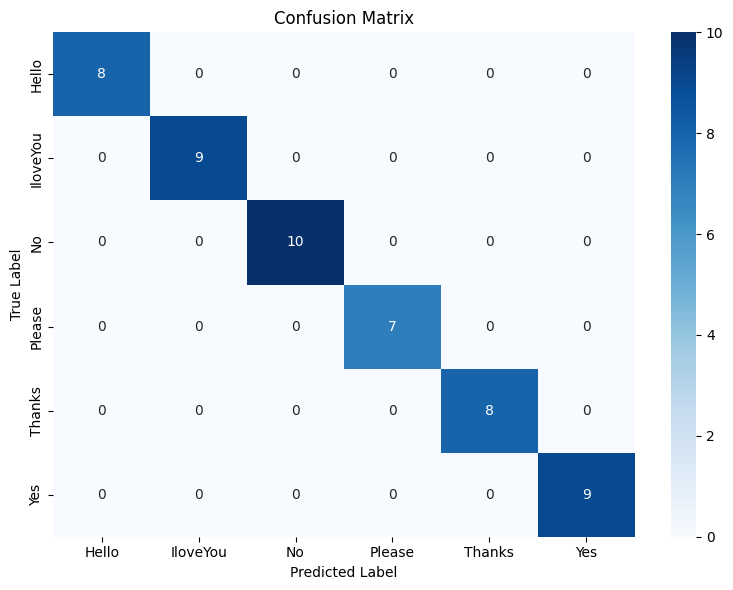

In [5]:
# Tạo confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=class_names)

# Vẽ heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()
